In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!unzip -o "/content/drive/MyDrive/datasets/archive (3).zip" -d /content/

Streaming output truncated to the last 5000 lines.
  inflating: /content/socofing/SOCOFing/Real/191__F_Left_index_finger.BMP  
  inflating: /content/socofing/SOCOFing/Real/191__F_Left_little_finger.BMP  
  inflating: /content/socofing/SOCOFing/Real/191__F_Left_middle_finger.BMP  
  inflating: /content/socofing/SOCOFing/Real/191__F_Left_ring_finger.BMP  
  inflating: /content/socofing/SOCOFing/Real/191__F_Left_thumb_finger.BMP  
  inflating: /content/socofing/SOCOFing/Real/191__F_Right_index_finger.BMP  
  inflating: /content/socofing/SOCOFing/Real/191__F_Right_little_finger.BMP  
  inflating: /content/socofing/SOCOFing/Real/191__F_Right_middle_finger.BMP  
  inflating: /content/socofing/SOCOFing/Real/191__F_Right_ring_finger.BMP  
  inflating: /content/socofing/SOCOFing/Real/191__F_Right_thumb_finger.BMP  
  inflating: /content/socofing/SOCOFing/Real/192__M_Left_index_finger.BMP  
  inflating: /content/socofing/SOCOFing/Real/192__M_Left_little_finger.BMP  
  inflating: /content/socofin

In [ ]:
real_path = "/content/SOCOFing/Real"

altered_easy = "/content/SOCOFing/Altered/Altered-Easy"
altered_medium = "/content/SOCOFing/Altered/Altered-Medium"
altered_hard = "/content/SOCOFing/Altered/Altered-Hard"

In [ ]:
import os

print("Real:", len(os.listdir(real_path)))
print("Easy:", len(os.listdir(altered_easy)))
print("Medium:", len(os.listdir(altered_medium)))
print("Hard:", len(os.listdir(altered_hard)))

Real: 6000
Easy: 17931
Medium: 17067
Hard: 14272


In [ ]:
!pip install opencv-python
!pip install tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 760.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 142.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 104.5 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


(np.float64(-0.5), np.float64(95.5), np.float64(102.5), np.float64(-0.5))

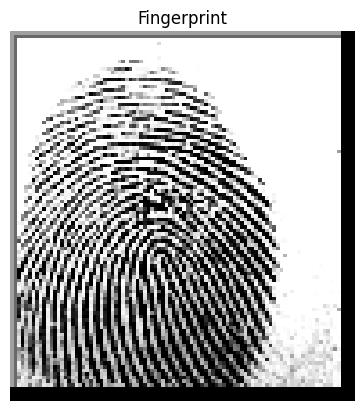

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

img_path = os.path.join(real_path, os.listdir(real_path)[0])

img = cv2.imread(img_path, 0)

plt.imshow(img, cmap="gray")
plt.title("Fingerprint")
plt.axis("off")

In [ ]:
data = []
labels = []

IMG_SIZE = 96

In [ ]:
for img in os.listdir(real_path):

    img_path = os.path.join(real_path, img)

    image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

    image = cv2.resize(image,(IMG_SIZE,IMG_SIZE))

    data.append(image)
    labels.append(0)

In [ ]:
for folder in [altered_easy, altered_medium, altered_hard]:

    for img in os.listdir(folder):

        img_path = os.path.join(folder, img)

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        image = cv2.resize(image,(IMG_SIZE,IMG_SIZE))

        data.append(image)
        labels.append(1)

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.model_selection import train_test_split

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
data = np.array(data)
labels = np.array(labels)

In [ ]:
data = data / 255.0

In [ ]:
data = data.reshape(-1,96,96,1)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    data, labels, test_size=0.2, random_state=42
)

In [ ]:
model = Sequential()

model.add(Conv2D(32,(3,3),activation='relu',input_shape=(96,96,1)))
model.add(MaxPooling2D(2,2))

model.add(Conv2D(64,(3,3),activation='relu'))
model.add(MaxPooling2D(2,2))

model.add(Flatten())

model.add(Dense(128,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_test,y_test)
)

Epoch 1/10
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 223s 161ms/step - accuracy: 0.9045 - loss: 0.2290 - val_accuracy: 0.9228 - val_loss: 0.1801
Epoch 2/10
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 222s 161ms/step - accuracy: 0.9338 - loss: 0.1549 - val_accuracy: 0.9405 - val_loss: 0.1378
Epoch 3/10
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 222s 161ms/step - accuracy: 0.9568 - loss: 0.1100 - val_accuracy: 0.9385 - val_loss: 0.1360
Epoch 4/10
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 221s 160ms/step - accuracy: 0.9651 - loss: 0.0863 - val_accuracy: 0.9675 - val_loss: 0.0855
Epoch 5/10
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 222s 161ms/step - accuracy: 0.9717 - loss: 0.0707 - val_accuracy: 0.9702 - val_loss: 0.0785
Epoch 6/10
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 221s 160ms/step - accuracy: 0.9776 - loss: 0.0572 - val_accuracy: 0.9699 - val_loss: 0.0747
Epoch 7/10
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 221s 160ms/step - accuracy: 0.9816 - loss: 0.0494 - val_accuracy: 0.9695 - val_loss: 0.0804
Epoch 8/10
1382/1382 ━━━━━━━━━━━━━━━━━━━━ 222s 161ms/step - ac

In [ ]:
loss,accuracy = model.evaluate(X_test,y_test)

print("Accuracy:",accuracy)

346/346 ━━━━━━━━━━━━━━━━━━━━ 11s 33ms/step - accuracy: 0.9694 - loss: 0.1143
Accuracy: 0.9694228172302246


In [ ]:
import cv2
import numpy as np


if not os.path.exists("/content/test_fingerprint.bmp"):
    dummy_img = np.zeros((96, 96), dtype=np.uint8)
    cv2.imwrite("/content/test_fingerprint.bmp", dummy_img)
    print("Created a dummy test_fingerprint.bmp for demonstration.")

img = cv2.imread("/content/test_fingerprint.bmp", 0)

if img is None:
    print("Error: Could not load image from /content/test_fingerprint.bmp. Please ensure the file exists and the path is correct.")
else:
    img = cv2.resize(img, (96, 96))
    img = img / 255.0
    img = img.reshape(1, 96, 96, 1)

    prediction = model.predict(img)

    if prediction > 0.5:
        print("Altered Fingerprint")
    else:
        print("Real Fingerprint")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
Real Fingerprint


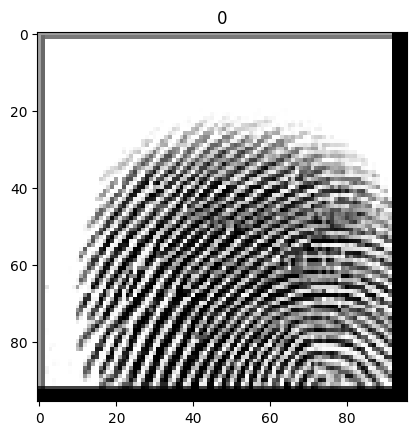

In [ ]:
plt.imshow(data[10].reshape(96,96),cmap='gray')
plt.title(labels[10])
plt.show()